# Processed Landmark Dataset — Exploration

Explores the output of `scripts/process_dataset.py`: the per-frame `combined_landmarks.csv`
for each split (face landmarks + MAR + label, joined from the raw CSVs). Focus: how much
of the raw dataset actually got a usable face detection, class balance after that filtering,
the Mouth Aspect Ratio (MAR) signal by label, and a visual look at annotated landmark
crops — both successful detections and failures.

## 1. Setup & Imports

### Imports, paths and plot style

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage

from config import (
    DATA_PROCESSED_DIR,
    RAW_CLIPS_VIDEOS_DIR,
    COMBINED_LANDMARKS_FILENAME,
    SPLITS,
    NUM_FACE_LANDMARKS,
)
from extract_landmarks import PersonLandmarkExtractor

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RNG = np.random.default_rng(0)

METADATA_COLS = ["person_id", "video_id", "image_name", "detected", "mar", "target", "target_index"]
PROCESSED_PATHS = {split: DATA_PROCESSED_DIR / split / COMBINED_LANDMARKS_FILENAME for split in SPLITS}
PROCESSED_PATHS

{'train': PosixPath('/data/bola/Train RNN ASD/data/processed/train/combined_landmarks.csv'),
 'val': PosixPath('/data/bola/Train RNN ASD/data/processed/val/combined_landmarks.csv')}

### Load processed metadata (train + val)

These CSVs are large (22 GB train / 8 GB val, 1441 columns — 478 landmarks × xyz).
We only need the 7 metadata columns for the stats below, and the `pyarrow` CSV engine
reads far faster than the default C engine on a file this wide, so we use it here and
only touch individual landmark columns later, per-row, for the picture visualizations.

In [2]:
def load_metadata(split: str) -> pd.DataFrame:
    df = pd.read_csv(PROCESSED_PATHS[split], usecols=METADATA_COLS, engine="pyarrow")
    df["split"] = split
    return df

meta = {split: load_metadata(split) for split in SPLITS}
meta_all = pd.concat(meta.values(), ignore_index=True)

for split in SPLITS:
    print(f"[{split}] {len(meta[split]):,} rows, {meta[split]['person_id'].nunique():,} person tracks, "
          f"{meta[split]['video_id'].nunique():,} videos")
meta_all.head()

[train] 3,001,883 rows, 36,791 person tracks, 95 videos
[val] 998,644 rows, 11,902 person tracks, 22 videos


,person_id,video_id,image_name,detected,mar,target,target_index,split
0,-ASZexdSdWE:100,-ASZexdSdWE,92.68.jpg,False,NaN,NOT_SPEAKING,0,train
1,-ASZexdSdWE:100,-ASZexdSdWE,92.72.jpg,False,NaN,NOT_SPEAKING,0,train
2,-ASZexdSdWE:100,-ASZexdSdWE,92.76.jpg,False,NaN,NOT_SPEAKING,0,train
3,-ASZexdSdWE:100,-ASZexdSdWE,92.80.jpg,False,NaN,NOT_SPEAKING,0,train
4,-ASZexdSdWE:100,-ASZexdSdWE,92.84.jpg,False,NaN,NOT_SPEAKING,0,train


## 2. Detection Rate

### Overall % of frames with a detected face, per split

In [3]:
detection_rate = meta_all.groupby("split")["detected"].mean().mul(100).round(2)
detection_counts = meta_all.groupby("split")["detected"].agg(["sum", "count"])
detection_counts["pct_detected"] = (detection_counts["sum"] / detection_counts["count"] * 100).round(2)
detection_counts.rename(columns={"sum": "detected_frames", "count": "total_frames"})

,detected_frames,total_frames,pct_detected
split,,,
train,1533804,3001883,51.09
val,594457,998644,59.53


Overall detection rate across train+val: 53.20% (2,128,261 / 4,000,527 frames)


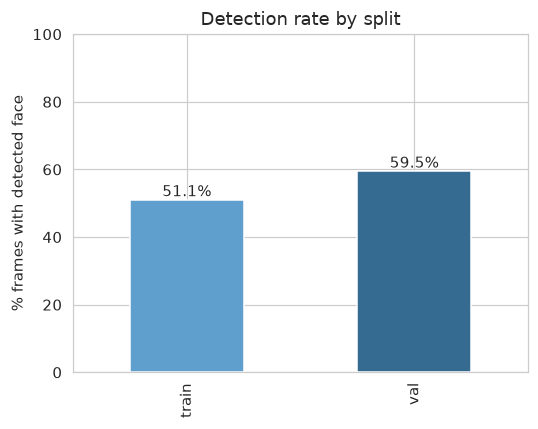

In [4]:
overall_pct = meta_all["detected"].mean() * 100
print(f"Overall detection rate across train+val: {overall_pct:.2f}% "
      f"({meta_all['detected'].sum():,} / {len(meta_all):,} frames)")

fig, ax = plt.subplots(figsize=(5, 4))
detection_rate.plot(kind="bar", ax=ax, color=sns.color_palette("Blues_d", len(detection_rate)))
ax.set_ylabel("% frames with detected face")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.set_title("Detection rate by split")
for i, v in enumerate(detection_rate):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

### Detection rate by label (SPEAKING_AUDIBLE vs NOT_SPEAKING)

Only rows with a matched label (`target` not null) are included — unmatched frames are covered separately below.

In [5]:
labeled = meta_all.dropna(subset=["target"])
det_by_label = labeled.groupby(["split", "target"])["detected"].mean().mul(100).round(2).unstack()
det_by_label

target,NOT_SPEAKING,SPEAKING_AUDIBLE
split,,
train,44.60,67.76
val,57.75,66.38


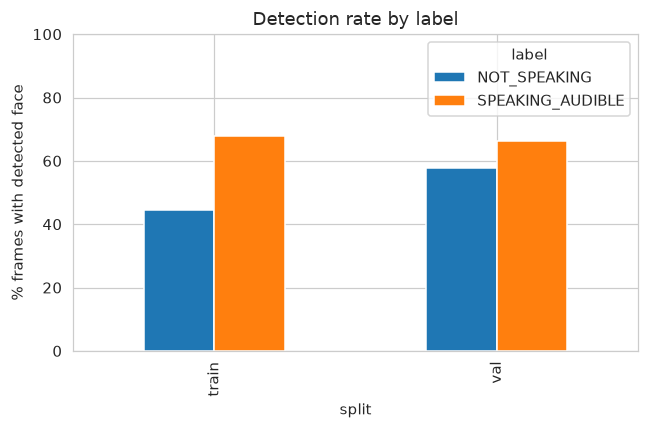

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
det_by_label.plot(kind="bar", ax=ax)
ax.set_ylabel("% frames with detected face")
ax.set_ylim(0, 100)
ax.set_title("Detection rate by label")
ax.legend(title="label")
plt.tight_layout()
plt.show()

### Per-person detection completeness

How consistently is a face detected *within* a track — are failures spread thinly across
many people, or concentrated in a subset of tracks (e.g. profile shots, heavy occlusion)?

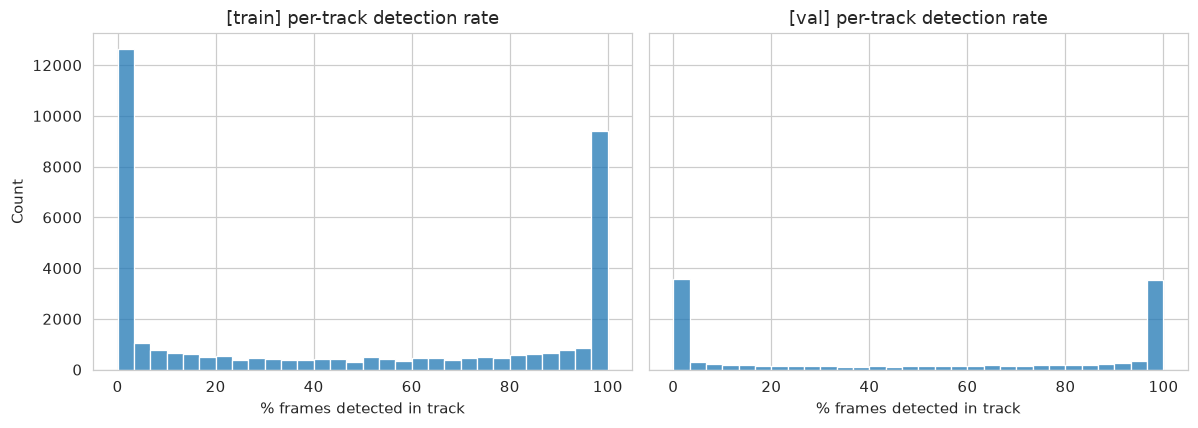

Tracks with <50% frame detection rate: 25,730 / 48,693 (52.8%)


In [7]:
person_det = meta_all.groupby(["split", "person_id"])["detected"].mean().mul(100).reset_index(name="pct_detected")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, split in zip(axes, SPLITS):
    sns.histplot(person_det.loc[person_det["split"] == split, "pct_detected"], bins=30, ax=ax)
    ax.set_title(f"[{split}] per-track detection rate")
    ax.set_xlabel("% frames detected in track")
plt.tight_layout()
plt.show()

low_detection = person_det[person_det["pct_detected"] < 50]
print(f"Tracks with <50% frame detection rate: {len(low_detection):,} / {len(person_det):,} "
      f"({len(low_detection) / len(person_det) * 100:.1f}%)")

## 3. Label Coverage

### Frames with no matching CSV label (`target` is null)

In [8]:
unmatched = meta_all["target"].isna()
unmatched_by_split = meta_all.groupby("split").apply(lambda d: d["target"].isna().mean() * 100, include_groups=False)
print("Overall unmatched-label rate: {:.3f}%".format(unmatched.mean() * 100))
unmatched_by_split.round(3)

Overall unmatched-label rate: 0.000%


split
train    0.0
val      0.0
dtype: float64

### Class balance in the processed dataset (labeled rows only)

target,NOT_SPEAKING,SPEAKING_AUDIBLE
split,,
train,2160075,841808
val,792938,205706


target,NOT_SPEAKING,SPEAKING_AUDIBLE
split,,
train,71.96,28.04
val,79.40,20.60


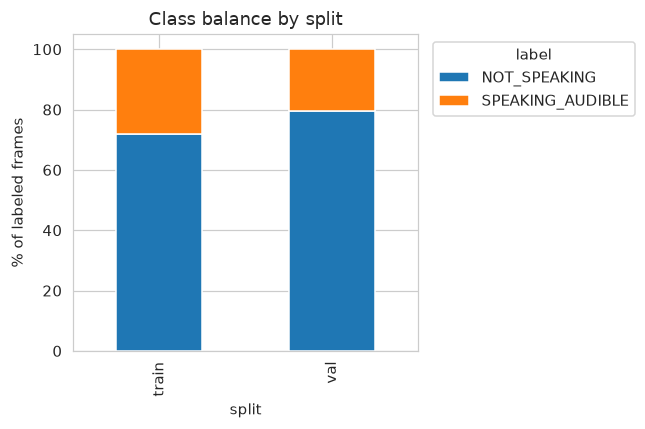

In [9]:
class_balance = labeled.groupby(["split", "target"]).size().unstack()
class_balance_pct = class_balance.div(class_balance.sum(axis=1), axis=0).mul(100).round(2)
display(class_balance)
display(class_balance_pct)

fig, ax = plt.subplots(figsize=(6, 4))
class_balance_pct.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("% of labeled frames")
ax.set_title("Class balance by split")
ax.legend(title="label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Mouth Aspect Ratio (MAR) by Label

MAR is only computed where a face was detected. Scale-invariant (ratio of distances), so raw vs. normalized landmark extraction doesn't affect it.

In [10]:
mar_df = labeled.dropna(subset=["mar"])
mar_stats = mar_df.groupby(["split", "target"])["mar"].describe()[["count", "mean", "std", "50%", "min", "max"]]
mar_stats

count      mean       std       50%       min  \
split target                                                               
train NOT_SPEAKING      963367.0  0.098007  0.117762  0.043074  0.000458   
      SPEAKING_AUDIBLE  570437.0  0.163048  0.126498  0.152946  0.000742   
val   NOT_SPEAKING      457900.0  0.099820  0.115372  0.051987  0.000467   
      SPEAKING_AUDIBLE  136557.0  0.170892  0.134573  0.156572  0.000994   

                              max  
split target                       
train NOT_SPEAKING      20.181821  
      SPEAKING_AUDIBLE   6.721185  
val   NOT_SPEAKING      10.448630  
      SPEAKING_AUDIBLE   2.220542

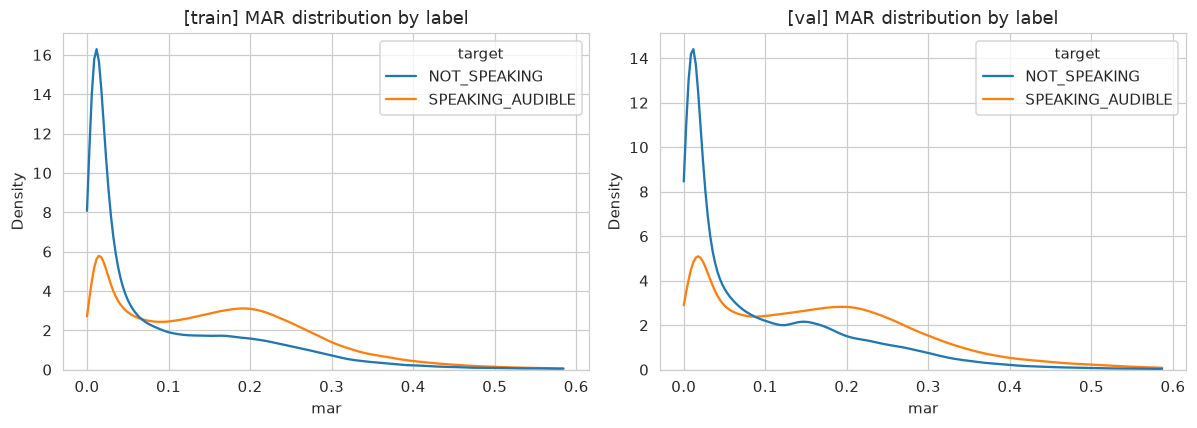

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, split in zip(axes, SPLITS):
    sub = mar_df[mar_df["split"] == split]
    sns.kdeplot(data=sub, x="mar", hue="target", common_norm=False, ax=ax, clip=(0, sub["mar"].quantile(0.995)))
    ax.set_title(f"[{split}] MAR distribution by label")
plt.tight_layout()
plt.show()

## 5. Annotated Landmark Pictures

Landmarks stored in the combined CSV are **normalized** (centered on the nose tip, scaled by
interocular distance) for training — not pixel coordinates — so they can't be drawn directly over
the original image. To visualize real annotated crops we re-run `PersonLandmarkExtractor` (raw,
non-normalized) on a handful of sample images, selected using what the processed CSV already told
us about each frame (detected vs. not, label).

### Helper: resolve a processed-CSV row to its raw image path, and run detection for display

In [12]:
extractor = PersonLandmarkExtractor(save_annotated=False, save_json=False, normalize=False)

def resolve_image_path(split: str, video_id: str, person_id: str, image_name: str) -> Path:
    return RAW_CLIPS_VIDEOS_DIR / split / video_id / person_id / image_name

def sample_rows(df: pd.DataFrame, n: int, detected: bool, target: str | None = None, seed: int = 0) -> pd.DataFrame:
    pool = df[df["detected"] == detected]
    if target is not None:
        pool = pool[pool["target"] == target]
    # one frame per distinct person_id, for visual diversity across tracks
    pool = pool.drop_duplicates(subset="person_id")
    return pool.sample(n=min(n, len(pool)), random_state=seed)

def show_grid(rows: pd.DataFrame, title: str, cols: int = 4):
    n = len(rows)
    rows_n = -(-n // cols)
    fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 3.2 * rows_n))
    axes = np.atleast_1d(axes).flatten()
    for ax, (_, row) in zip(axes, rows.iterrows()):
        img_path = resolve_image_path(row["split"], row["video_id"], row["person_id"], row["image_name"])
        image, record = extractor._extract_image(img_path)
        ax.imshow(image)
        if record["detected"]:
            face = np.array(record["face_landmarks"])
            ax.scatter(face[:, 0], face[:, 1], s=2, c="lime", alpha=0.6)
            mouth = np.array(record["mouth_landmarks"])
            ax.scatter(mouth[:, 0], mouth[:, 1], s=6, c="cyan")
        else:
            ax.text(0.5, 0.5, "no face\n(re-run)", ha="center", va="center", transform=ax.transAxes, color="red")
        ax.set_title(f'{row["target"]}\n{row["person_id"]}', fontsize=7)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

W0000 00:00:1784127528.143732  381968 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1784127528.201202  381968 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1784127528.254988  382019 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 580.159.03), renderer: NVIDIA RTX PRO 6000 Blackwell Server Edition/PCIe/SSE2


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


### Successful detections — SPEAKING_AUDIBLE vs NOT_SPEAKING

E0000 00:00:1784127528.736806  382019 tensor.cc:404] Tensors are designed for single writes. Multiple writes to a Tensor instance are not supported and may lead to undefined behavior due to lack of synchronization.


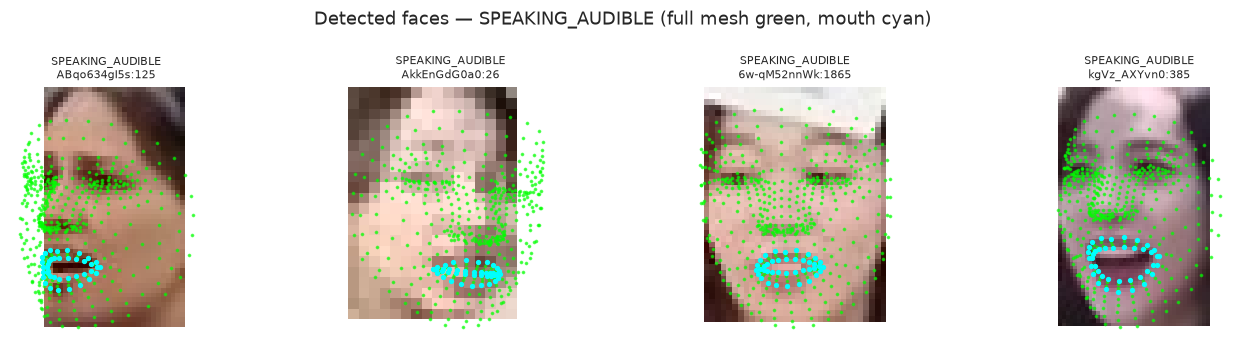

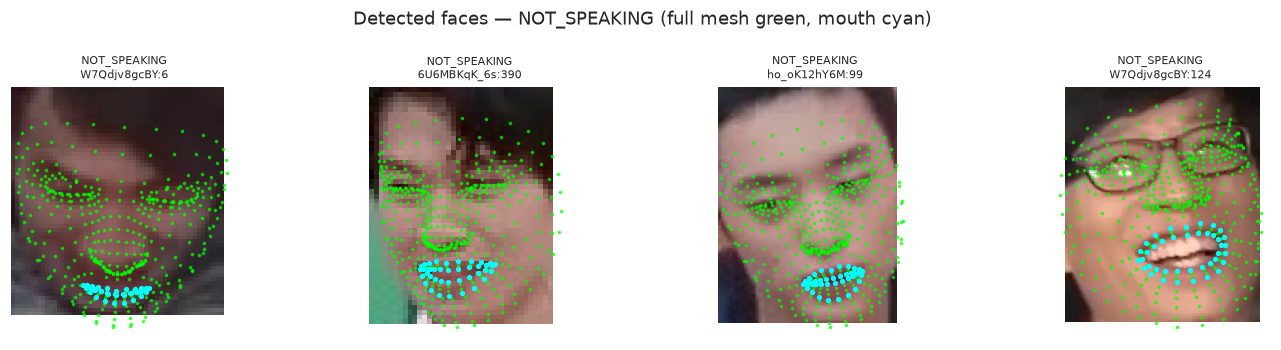

In [13]:
val_labeled = meta["val"].dropna(subset=["target"])

speaking_ok = sample_rows(val_labeled, n=4, detected=True, target="SPEAKING_AUDIBLE", seed=1)
not_speaking_ok = sample_rows(val_labeled, n=4, detected=True, target="NOT_SPEAKING", seed=1)

show_grid(speaking_ok, "Detected faces — SPEAKING_AUDIBLE (full mesh green, mouth cyan)")
show_grid(not_speaking_ok, "Detected faces — NOT_SPEAKING (full mesh green, mouth cyan)")

### Detection failures

Frames the pipeline marked `detected=False` — the extractor is re-run above just to fetch the raw image for display; it will fail again by definition, so these panels show the raw crop only.

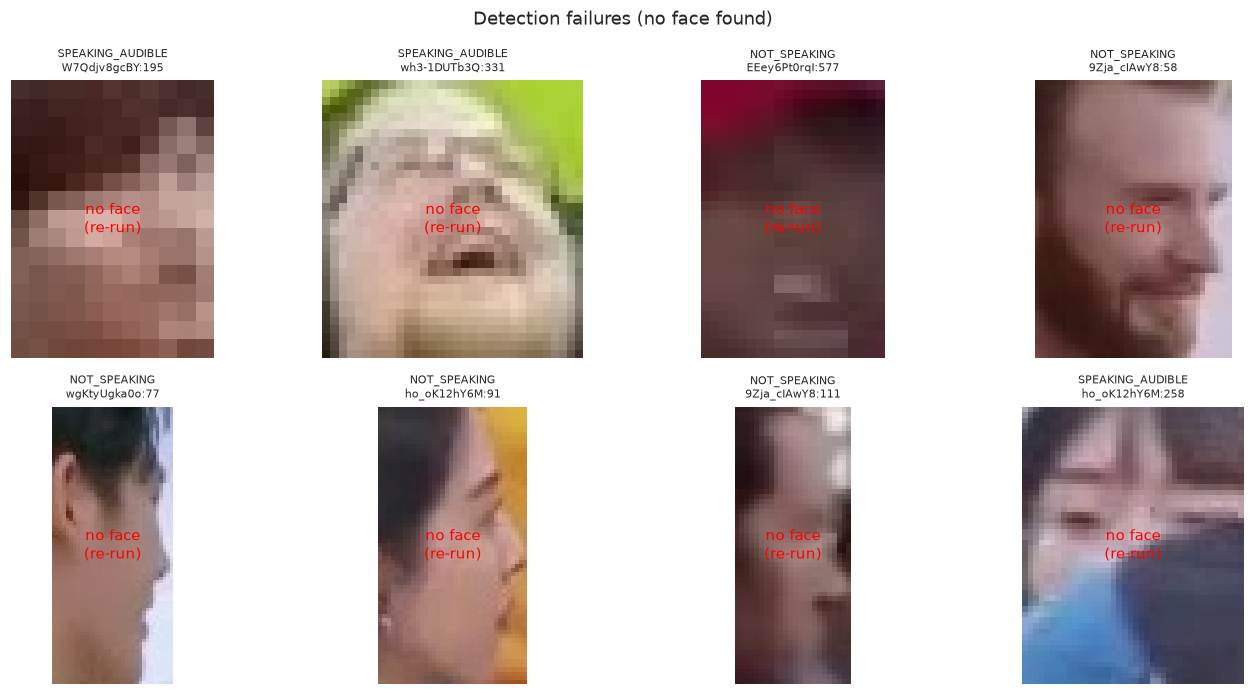

In [14]:
failed = sample_rows(meta["val"], n=8, detected=False, seed=2)
show_grid(failed, "Detection failures (no face found)")

## 6. Summary

### Key numbers at a glance

In [15]:
summary = pd.DataFrame({
    "total_frames": meta_all.groupby("split").size(),
    "detected_frames": meta_all.groupby("split")["detected"].sum(),
    "pct_detected": meta_all.groupby("split")["detected"].mean().mul(100).round(2),
    "unmatched_label_pct": meta_all.groupby("split").apply(lambda d: d["target"].isna().mean() * 100, include_groups=False).round(3),
    "n_person_tracks": meta_all.groupby("split")["person_id"].nunique(),
    "n_videos": meta_all.groupby("split")["video_id"].nunique(),
})
summary

,total_frames,detected_frames,pct_detected,unmatched_label_pct,n_person_tracks,n_videos
split,,,,,,
train,3001883,1533804,51.09,0.0,36791,95
val,998644,594457,59.53,0.0,11902,22
